# Improved Ensemble Backtest
**Signals:** SPD Momentum · MVRV/RAP · Fear & Greed · Drawdown · MSTR · Polymarket (Fed + ETH)

Run cells **top to bottom**. Each cell is one step.

---
## Cell 1 — Install dependencies
Only needed the first time. Skip if already installed.

In [1]:
# Run once, then you can skip this cell
%pip install pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


---
## Cell 2 — Imports & path setup
Adds your `template/` folder to Python's module search path so imports work from the notebook.

In [2]:
import sys
import pandas as pd
import logging
from pathlib import Path

# ── Point to your project root ────────────────────────────────────────────────
# If your notebook is IN the project root (same level as the template/ folder),
# this line works as-is.
# If your notebook is somewhere else, change this to the correct path:
#   PROJECT_ROOT = Path("/absolute/path/to/your_project")
PROJECT_ROOT = Path(".").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"template/ exists : {(PROJECT_ROOT / 'template').exists()}")
print(f"data/ exists     : {(PROJECT_ROOT / 'data').exists()}")

logging.basicConfig(
    format="%(asctime)s %(levelname)-8s %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
)

Project root : /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies
template/ exists : True
data/ exists     : True


---
## Cell 3 — Import template modules

In [3]:
from template.prelude_template import load_data
from template.model_development_template import precompute_features
from template.backtest_template import compute_weights_modal, run_full_analysis
import template.backtest_template as bt

print("All imports OK")

All imports OK


---
## Cell 4 — Load BTC data

In [4]:
btc_df = load_data()

print(f"Rows   : {len(btc_df):,}")
print(f"Range  : {btc_df.index.min().date()} → {btc_df.index.max().date()}")
print(f"Columns: {list(btc_df.columns[:8])} ...")
btc_df[["PriceUSD_coinmetrics"]].tail(3)

2026-05-11 17:26:24 INFO     Loading CoinMetrics BTC data from local file: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/data/Coin Metrics/coinmetrics_btc.csv
2026-05-11 17:26:24 WARNING  Missing BTC-USD prices for 1 dates from 2018-01-01 to 2026-01-14. First missing date: 2026-01-14
2026-05-11 17:26:24 INFO     Loaded CoinMetrics data: 6221 rows, 2009-01-03 to 2026-01-14


Rows   : 6,221
Range  : 2009-01-03 → 2026-01-14
Columns: ['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime', 'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD', 'CapMrktEstUSD'] ...


,PriceUSD_coinmetrics
time,
2026-01-12,91141.149849
2026-01-13,95304.498294
2026-01-14,NaN


---
## Cell 5 — Attach Polymarket signals

Loads the three signal CSVs and attaches `poly_fed_signal` and `poly_eth_signal` to `btc_df`.  
`precompute_features()` in Cell 6 picks them up automatically via `_load_poly_score()`.  

Files needed in `data/Polymarket/signals/`:  
- `fed_signal.csv` — columns: `date`, `fed_signal`  
- `eth_bearish.csv` — columns: `date`, `eth_bearish_signal`  
- `eth_bullish.csv` — columns: `date`, `signal` (DD/MM/YYYY format)


In [5]:
# Load Polymarket signal CSVs (fed_signal.csv, eth_bearish.csv, eth_bullish.csv)
# Place files in: data/Polymarket/signals/

SIG_DIR = PROJECT_ROOT / 'data' / 'Polymarket' / 'signals'

def _load_sig(filename, col, datefmt=None):
    path = SIG_DIR / filename
    if not path.exists():
        print(f'  MISSING: {filename} -- using zeros')
        return pd.Series(dtype=float)
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'], format=datefmt if datefmt else 'mixed', dayfirst=True)
    return pd.to_numeric(df.set_index('date')[col], errors='coerce').fillna(0.0)

fed_raw      = _load_sig('fed_signal.csv',    col='fed_signal')
eth_bear_raw = _load_sig('eth_bearish.csv',   col='eth_bearish_signal')
eth_bull_raw = _load_sig('eth_bullish.csv',   col='signal', datefmt='%d/%m/%Y')

# Fed signal: bullish for BTC when rate-cut odds rise
poly_fed = fed_raw.resample('D').mean().ffill(limit=3).fillna(0.0).clip(-0.5, 0.5)

# ETH signal: combine bearish (flipped) + bullish
eth_bear_signed = -eth_bear_raw.resample('D').mean().ffill(limit=3).fillna(0.0)
eth_bull_signed =  eth_bull_raw.resample('D').mean().ffill(limit=3).fillna(0.0)
poly_eth = pd.concat([eth_bear_signed, eth_bull_signed], axis=1).mean(axis=1).clip(-0.5, 0.5)

btc_df['poly_fed_signal'] = poly_fed.reindex(btc_df.index).fillna(0.0)
btc_df['poly_eth_signal'] = poly_eth.reindex(btc_df.index).fillna(0.0)

print('Polymarket signals attached')
print(f'  Fed non-zero days : {(btc_df["poly_fed_signal"] != 0).sum()}')
print(f'  ETH non-zero days : {(btc_df["poly_eth_signal"] != 0).sum()}')
print(f'  Signal window     : Apr 2025 – Jan 2026 (only recent data available)')


Polymarket signals attached
  Fed non-zero days : 241
  ETH non-zero days : 270
  Signal window     : Apr 2025 – Jan 2026 (only recent data available)


---
## Cell 5b — Attach MSTR signal

Loads `mstr_buy_signal.csv` and attaches it as `mstr_btc_purchased` column on `btc_df`.  
`precompute_features()` in Cell 6 picks this up automatically via `_load_mstr_signal()`.  

File location: `data/mstr_buy_signal.csv`  
Columns: `purchase_date`, `btc_amount`, `avg_cost_usd`, `cumulative_btc`

In [6]:
# Load MSTR purchase events → btc_df['mstr_btc_purchased']
# precompute_features() reads this column automatically in _load_mstr_signal()

mstr_candidates = [
    PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv',
]

mstr_path = next((p for p in mstr_candidates if p.exists()), None)

if mstr_path:
    mstr_raw = pd.read_csv(mstr_path)

    # Parse dates — handles YYYY-MM-DD, DD/MM/YYYY, YYYY/M/D automatically
    mstr_raw['date'] = pd.to_datetime(
        mstr_raw['purchase_date'], dayfirst=True, format='mixed'
    )
    mstr_raw = mstr_raw.set_index('date').sort_index()

    # Sum btc_amount if multiple purchases on the same day
    mstr_daily = mstr_raw['btc_amount'].groupby(level=0).sum()

    # Attach to btc_df — non-event days get 0
    btc_df['mstr_btc_purchased'] = mstr_daily.reindex(btc_df.index).fillna(0.0)

    n_events  = (btc_df['mstr_btc_purchased'] > 0).sum()
    total_btc = mstr_daily.sum()
    print(f'MSTR signal attached:')
    print(f'  Purchase events : {n_events}')
    print(f'  Total BTC       : {total_btc:,.0f}')
    print(f'  Date range      : {mstr_daily.index.min().date()} to {mstr_daily.index.max().date()}')
    print(f'  Largest buy     : {mstr_daily.max():,.0f} BTC on {mstr_daily.idxmax().date()}')
else:
    print('MSTR: mstr_buy_signal.csv not found')
    print('  Tried:')
    for p in mstr_candidates:
        print(f'    {p}')
    print('  precompute_features() will use neutral proxy (signal = 0)')
    btc_df['mstr_btc_purchased'] = 0.0


MSTR signal attached:
  Purchase events : 94
  Total BTC       : 818,871
  Date range      : 2020-08-10 to 2026-05-11
  Largest buy     : 55,500 BTC on 2024-11-25


---
## Cell 6 — Precompute features
Computes all 6 signals from the raw data. Run once, reuse below.

In [7]:
features_df = precompute_features(btc_df)

# Set on backtest module so compute_weights_modal can find it
bt._FEATURES_DF = features_df

print(f"Features shape : {features_df.shape}")
print(f"Columns        : {list(features_df.columns)}")
features_df.tail(3)

Features shape : (5660, 6)
Columns        : ['PriceUSD_coinmetrics', 'price_vs_ma200', 'dd_365', 'mstr_signal', 'poly_score', 'cycle_mod']


,PriceUSD_coinmetrics,price_vs_ma200,dd_365,mstr_signal,poly_score,cycle_mod
time,,,,,,
2026-01-12,91141.149849,-0.146308,-0.273242,1.557019,0.0,1.0
2026-01-13,95304.498294,-0.141678,-0.269845,2.000000,0.0,1.0
2026-01-14,NaN,-0.101971,-0.236492,2.000000,0.0,1.0


---
## Cell 7 — Quick sanity check
Verifies weights sum to 1.0 on a single window before running the full backtest.

In [8]:
import pandas as pd
from template.model_development_template import compute_window_weights

start = pd.Timestamp("2022-01-01")
end   = pd.Timestamp("2023-01-01")

w = compute_window_weights(features_df, start, end, current_date=end)

print(f"Window       : {start.date()} → {end.date()}")
print(f"Weights sum  : {w.sum():.8f}  (should be 1.0)")
print(f"Min weight   : {w.min():.6f}  (should be > 0)")
print(f"Max weight   : {w.max():.6f}")

assert abs(w.sum() - 1.0) < 1e-5, "FAIL: weights don't sum to 1"
assert (w >= 0).all(), "FAIL: negative weights"
print("\n✅ Sanity check passed")

Window       : 2022-01-01 → 2023-01-01
Weights sum  : 1.00000000  (should be 1.0)
Min weight   : 0.001567  (should be > 0)
Max weight   : 0.004773

✅ Sanity check passed


---
## Cell 8 — Run full backtest
Runs all rolling windows and generates all charts.  
**Expected time: 2–5 minutes.**

In [9]:
OUTPUT_DIR = PROJECT_ROOT / "output"

run_full_analysis(
    btc_df=btc_df,
    features_df=features_df,
    compute_weights_fn=compute_weights_modal,
    output_dir=OUTPUT_DIR,
    strategy_label="Improved Ensemble (SPD + DD + MSTR + Polymarket)",
)

print(f"\nAll outputs saved to: {OUTPUT_DIR}")

2026-05-11 17:26:39 INFO     Running SPD backtest for 'Improved Ensemble (SPD + DD + MSTR + Polymarket)'...
2026-05-11 17:26:39 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-11 17:26:44 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-05-11 17:26:44 INFO     Aggregated Metrics for Improved Ensemble (SPD + DD + MSTR + Polymarket):
2026-05-11 17:26:44 INFO       SPD: min=1004.68, max=19778.55, mean=6679.89, median=3964.50
2026-05-11 17:26:44 INFO       Percentile: min=19.76%, max=68.69%, mean=39.74%, median=39.73%
2026-05-11 17:26:44 INFO       Exp-decay avg SPD percentile: 42.89%
2026-05-11 17:26:44 INFO     Running strategy validation...


Validating strategy submission readiness...


2026-05-11 17:26:52 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-11 17:26:57 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)



⚠️ Windows where strategy underperformed Uniform DCA:


,dynamic_percentile,uniform_percentile,Delta
window,,,
2018-05-11 → 2019-05-11,40.548076,40.672318,-0.124242
2018-05-13 → 2019-05-13,40.141357,40.721271,-0.579914
2018-05-14 → 2019-05-14,39.884127,40.637999,-0.753872
2018-05-15 → 2019-05-15,38.972087,39.993429,-1.021342
2018-05-16 → 2019-05-16,39.204953,40.006481,-0.801529
...,...,...,...
2024-09-14 → 2025-09-14,29.260955,30.525405,-1.264450
2024-09-15 → 2025-09-15,29.214754,30.284474,-1.069720
2024-09-16 → 2025-09-16,29.118440,30.033019,-0.914579


2026-05-11 17:26:57 INFO     Final Model Score: 53.18%
2026-05-11 17:26:57 INFO       Excess percentile: mean=1.04%, median=1.19%
2026-05-11 17:26:57 INFO       Relative improvement: mean=2.66%, median=3.07%
2026-05-11 17:26:57 INFO       Ratio (dynamic/uniform): mean=1.03, median=1.03
2026-05-11 17:26:57 INFO     Generating visualizations...



Summary: 934/2557 underperformed (63.47% win rate)
✅ Strategy meets performance requirement (≥ 50% win rate vs. uniform DCA).

✅ Strategy is ready for submission.


2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/performance_comparison.svg
2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/excess_percentile_distribution.svg
2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/win_loss_comparison.svg
2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/cumulative_performance.svg
2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/metrics_summary.svg
2026-05-11 17:26:58 INFO     ✓ Saved: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output/metrics.json
2026-05-11 17:26:58 INFO     All


All outputs saved to: /Users/mig/Documents/LSE/Capstone Project/P2_2025_26_ImprovingBitcoinAccumulationStrategies/output


---
## Cell 9 — Display charts inline
Shows all output charts directly in the notebook.

### Strategy vs Uniform DCA over time

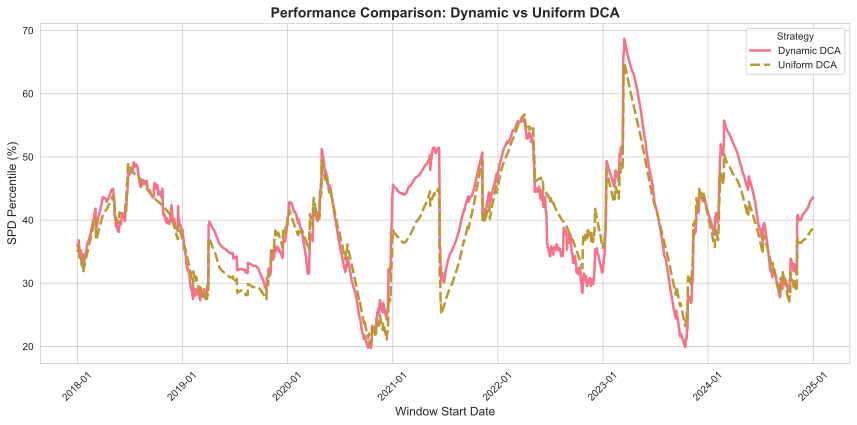

### Distribution of improvement

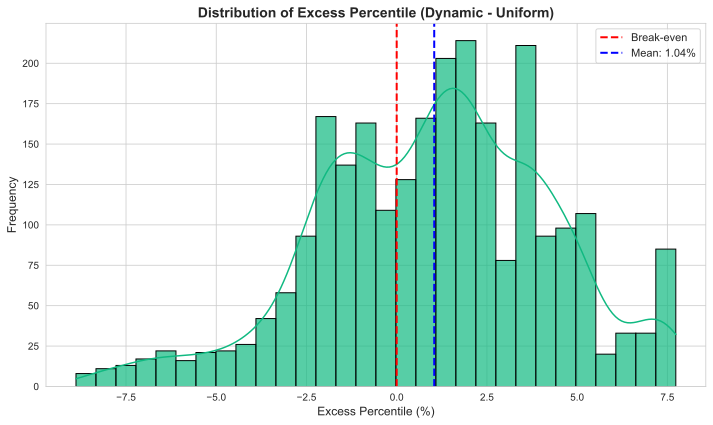

### Win / loss count

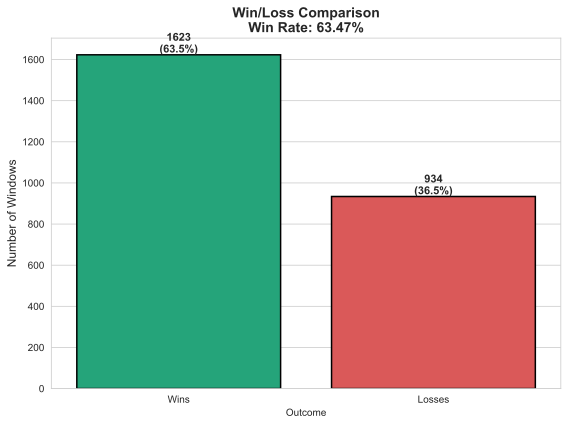

### Cumulative advantage

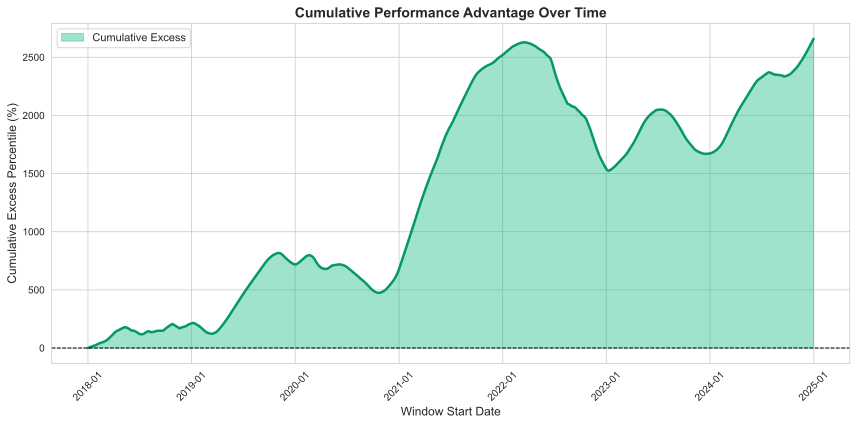

### Summary metrics table

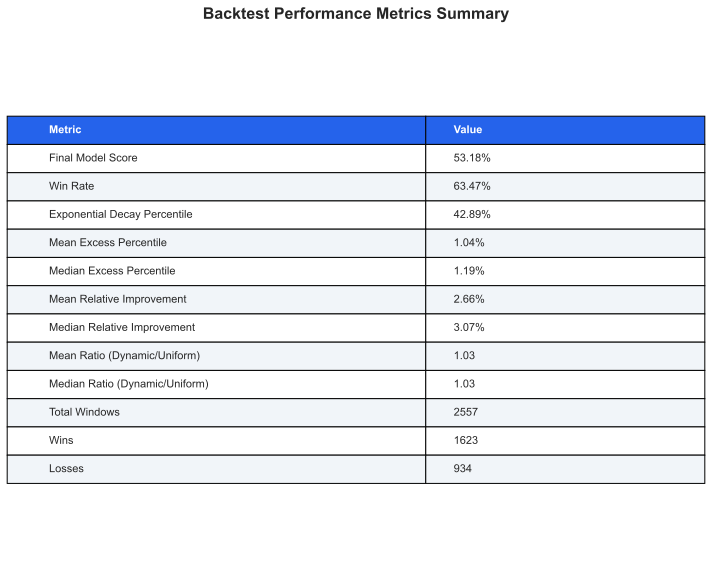

In [10]:
import json
from IPython.display import SVG, display, Markdown

charts = [
    ("performance_comparison.svg",        "Strategy vs Uniform DCA over time"),
    ("excess_percentile_distribution.svg", "Distribution of improvement"),
    ("win_loss_comparison.svg",            "Win / loss count"),
    ("cumulative_performance.svg",         "Cumulative advantage"),
    ("metrics_summary.svg",                "Summary metrics table"),
]

for filename, title in charts:
    path = OUTPUT_DIR / filename
    if path.exists():
        display(Markdown(f"### {title}"))
        display(SVG(filename=str(path)))
    else:
        print(f"Not found: {filename}")

---
## Cell 10 — Print key metrics
Reads `metrics.json` and prints the numbers you need for your demo.

In [11]:
with open(OUTPUT_DIR / "metrics.json") as f:
    metrics = json.load(f)["summary_metrics"]

print("="*45)
print("  BACKTEST RESULTS")
print("="*45)
print(f"  Final score            : {metrics['score']:.2f}%")
print(f"  Win rate               : {metrics['win_rate']:.2f}%")
print(f"  Exp-decay percentile   : {metrics['exp_decay_percentile']:.2f}%")
print(f"  Mean excess percentile : {metrics['mean_excess']:.2f} pp")
print(f"  Median excess          : {metrics['median_excess']:.2f} pp")
print(f"  Mean relative improv.  : {metrics['relative_improvement_pct_mean']:.2f}%")
print(f"  Wins / Losses          : {metrics['wins']} / {metrics['losses']}")
print(f"  Total windows          : {metrics['total_windows']}")
print("="*45)

  BACKTEST RESULTS
  Final score            : 53.18%
  Win rate               : 63.47%
  Exp-decay percentile   : 42.89%
  Mean excess percentile : 1.04 pp
  Median excess          : 1.19 pp
  Mean relative improv.  : 2.66%
  Wins / Losses          : 1623 / 934
  Total windows          : 2557


---
## Cell 11 — (Optional) Ablation: test each signal's contribution
Shows how much each signal adds on top of the previous one.  
This is the table you show in your demo as evidence.

In [12]:
# Ablation test: add one signal at a time, measure SPD percentile improvement
# Shows each signal's contribution — key evidence for your demo.

import numpy as np
import pandas as pd
from template.prelude_template import backtest_dynamic_dca, compute_cycle_spd
from template.model_development_template import allocate_sequential_stable, _clean, MIN_W
from pathlib import Path

# ── MSTR helpers (same as tune_weights.ipynb) ────────────────────────────────
def _load_mstr_events_abl():
    for p in [
        PROJECT_ROOT / 'data' / 'Polymarket' / 'signals' / 'mstr_buy_signal.csv',
        PROJECT_ROOT / 'data' / 'mstr_buy_signal.csv',
    ]:
        if p.exists():
            return pd.to_datetime(
                pd.read_csv(p)['purchase_date'], dayfirst=True, format='mixed'
            ).sort_values()
    return pd.DatetimeIndex([])

def _mstr_hit(index, evt_dates, lookback=7, count_mode=True):
    if len(index) == 0 or len(evt_dates) == 0:
        return np.zeros(len(index))
    idx = pd.DatetimeIndex(index).tz_localize(None)
    full = pd.date_range(idx.min(), idx.max(), freq='D')
    s = pd.Series(0, index=full, dtype=int)
    ev = evt_dates[(evt_dates >= full.min()) & (evt_dates <= full.max())]
    if len(ev): s.loc[ev] = 1
    win = s.rolling(lookback, min_periods=1).sum().reindex(idx, method='nearest')
    return win.values.astype(float) if count_mode else (win.values > 0).astype(float)

_abl_mstr_dates = _load_mstr_events_abl()
print(f'MSTR events for ablation: {len(_abl_mstr_dates)}')

def _spd_score(pma):
    s = np.ones_like(pma)
    s[pma < -0.20] = 1.8;  s[(pma >= -0.20) & (pma < -0.05)] = 1.3
    s[(pma >= -0.05) & (pma < 0.05)] = 1.0
    s[(pma >= 0.05) & (pma < 0.20)] = 0.8;  s[pma >= 0.20] = 0.6
    return s

# ── Ablation weight builder ───────────────────────────────────────────────────
def make_ablation_fn(config):
    """
    config keys (all bool, default False = signal off)
      spd   : SPD momentum
      dd    : drawdown multiplier
      mstr  : MSTR rolling-window boost
      poly  : Polymarket multiplier
    """
    def _w(df_window):
        start, end = df_window.index.min(), df_window.index.max()
        df = features_df.loc[start:end]
        if df.empty: return pd.Series(dtype=float)
        n    = len(df)
        base = np.ones(n) / n
        cmod = _clean(df['cycle_mod'].values) if 'cycle_mod' in df.columns else np.ones(n)

        # Stage 1: SPD (or flat 1.0 if off)
        core = _spd_score(_clean(df['price_vs_ma200'].values)) if config.get('spd') else np.ones(n)

        # Stage 2a: drawdown (or flat 1.0 if off)
        if config.get('dd'):
            dd = _clean(df['dd_365'].values)
            dd_m = np.full(n, 2.0)   # use best params from tune_weights
            for thr, m in [(-0.10, 0.7), (-0.20, 1.0), (-0.40, 1.3), (-0.60, 1.6)]:
                dd_m[dd > thr] = m
            dd_m *= cmod
        else:
            dd_m = np.ones(n)

        # Stage 2b: MSTR rolling-window boost (or flat 0 bonus if off)
        if config.get('mstr'):
            hit = _mstr_hit(df.index, _abl_mstr_dates, lookback=7, count_mode=True)
            mstr_bonus = 0.3 * hit   # reference default add_rel=0.3
        else:
            mstr_bonus = np.zeros(n)

        # Stage 2c: Polymarket (or flat 1.0 if off)
        if config.get('poly'):
            poly = _clean(df['poly_score'].values)
            poly_m = np.clip(1.0 + 0.1 * poly, 0.5, 1.5)
        else:
            poly_m = np.ones(n)

        raw = np.clip(base * core * dd_m * poly_m * (1 + mstr_bonus), MIN_W, None)
        return pd.Series(allocate_sequential_stable(raw, n), index=df.index)
    return _w

# ── Run ablation ──────────────────────────────────────────────────────────────
ablation_configs = {
    '0. Baseline (uniform DCA)':  {},
    '1. + SPD momentum':          {'spd': True},
    '2. + Drawdown':              {'spd': True, 'dd': True},
    '3. + MSTR':                  {'spd': True, 'dd': True, 'mstr': True},
    '4. + Polymarket (full)':     {'spd': True, 'dd': True, 'mstr': True, 'poly': True},
}

rows = []
for label, config in ablation_configs.items():
    tbl, exp_pct = backtest_dynamic_dca(
        btc_df, make_ablation_fn(config),
        features_df=features_df, strategy_label=label
    )
    excess = tbl['dynamic_percentile'] - tbl['uniform_percentile']
    rows.append({
        'Config':           label,
        'Median SPD pct':   round(tbl['dynamic_percentile'].median(), 2),
        'Median excess pp': round(excess.median(), 2),
        'Win rate %':       round((excess > 0).mean() * 100, 1),
        'Exp-decay pct':    round(exp_pct, 2),
    })

ablation_df = pd.DataFrame(rows).set_index('Config')
display(ablation_df)
print('\nEach row shows the cumulative effect of adding one more signal.')
print('Use this table as evidence in your demo.')


2026-05-11 17:27:09 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)


MSTR events for ablation: 109


2026-05-11 17:27:14 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-05-11 17:27:14 INFO     Aggregated Metrics for 0. Baseline (uniform DCA):
2026-05-11 17:27:14 INFO       SPD: min=986.08, max=19624.05, mean=6634.67, median=4075.67
2026-05-11 17:27:14 INFO       Percentile: min=20.29%, max=64.90%, mean=38.70%, median=38.49%
2026-05-11 17:27:14 INFO       Exp-decay avg SPD percentile: 38.15%
2026-05-11 17:27:14 INFO     Backtesting date range: 2018-01-01 to 2025-12-31 (2557 total windows)
2026-05-11 17:27:18 INFO     ✓ Validated weight sums for 2557 windows (all sum to 1.0)
2026-05-11 17:27:18 INFO     Aggregated Metrics for 1. + SPD momentum:
2026-05-11 17:27:18 INFO       SPD: min=998.65, max=19970.06, mean=6649.84, median=3946.16
2026-05-11 17:27:18 INFO       Percentile: min=19.38%, max=69.81%, mean=39.48%, median=38.96%
2026-05-11 17:27:18 INFO       Exp-decay avg SPD percentile: 41.67%
2026-05-11 17:27:18 INFO     Backtesting date range: 2018-01-01 to 2025

,Median SPD pct,Median excess pp,Win rate %,Exp-decay pct
Config,,,,
0. Baseline (uniform DCA),38.49,0.00,35.0,38.15
1. + SPD momentum,38.96,0.88,60.0,41.67
2. + Drawdown,39.50,0.93,61.0,42.38
3. + MSTR,39.50,1.06,61.9,41.99
4. + Polymarket (full),39.50,1.06,61.9,42.00



Each row shows the cumulative effect of adding one more signal.
Use this table as evidence in your demo.
